# Kalman Filter Intro

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

## Stationary Target

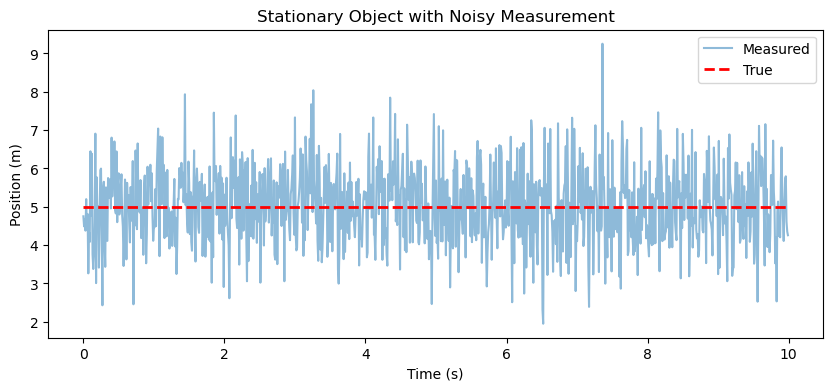

In [10]:
# Generating Stationary Object and Noisy Position Measurements

delta_t = .01
end_time = 10.0
t = np.arange(0, end_time, delta_t)

x_actual = 5.0

# instrument noise 
sensor_noise = 1.0
x_measured = x_actual + np.random.normal(0, sensor_noise, size = len(t))

x_actual_array = np.full(len(t), x_actual)

plt.figure(figsize = (10, 4))
plt.plot(t, x_measured, '-', alpha = 0.5, label = 'Measured')
plt.plot(t, x_actual_array, 'r--', linewidth = 2, label = 'True')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Stationary Object with Noisy Measurement')
plt.legend()
plt.show()

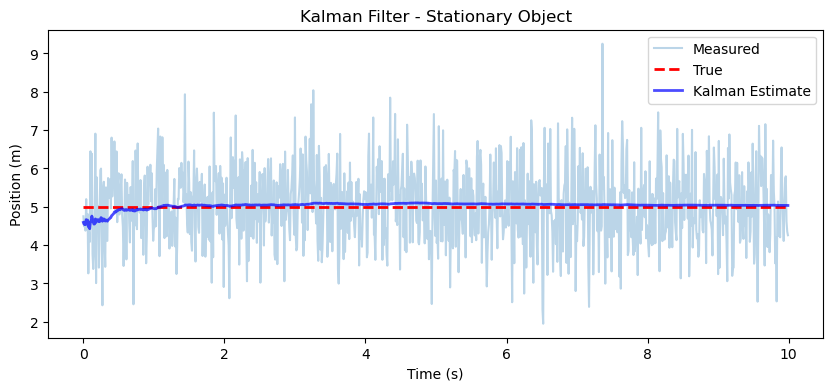

In [11]:
# Kalman Filter for Stationary Object

x_estd = 3.0
P = 10.0  # initial uncertainty
Q = 0.0   # our constant-position model describes the object's behavior perfectly
R = 1.0   # variance of instrument noise (our random noise has std 1.0)

estimates = []
for val in x_measured:
    x_pred = x_estd
    P_pred = P + Q
    K = P_pred / (P_pred + R)
    P = (1 - K) * P_pred
    # generate new x estimate
    x_estd = x_pred + K * (val - x_pred)
    estimates.append(x_estd)
   
plt.figure(figsize = (10, 4))
plt.plot(t, x_measured, alpha = 0.3, label = 'Measured')
plt.plot(t, x_actual_array, 'r--', linewidth = 2, label = 'True')
plt.plot(t, estimates, 'b-', linewidth = 2, alpha = .7, label = 'Kalman Estimate')
plt.title('Kalman Filter - Stationary Object')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.show()

## Constant-Velocity Target

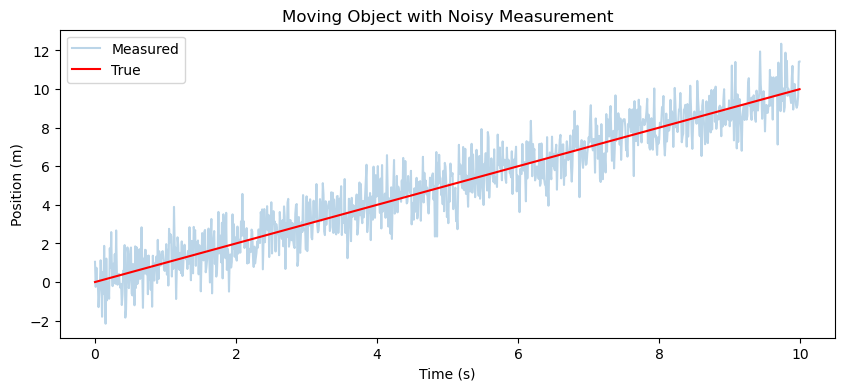

In [12]:
# Generating Position Data for Constant-Velocity Object

x_0_true = 0.0
v_true = 1.0
v_true_array = np.full(len(t), v_true)
x_true_moving = x_0_true + v_true*t
x_measured_moving = x_true_moving + np.random.normal(0, sensor_noise, size=len(t))

plt.figure(figsize=(10,4))
plt.plot(t, x_measured_moving, alpha = 0.3, label = 'Measured')
plt.plot(t, x_true_moving, 'r-', label = 'True')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Moving Object with Noisy Measurement')
plt.legend()
plt.show()

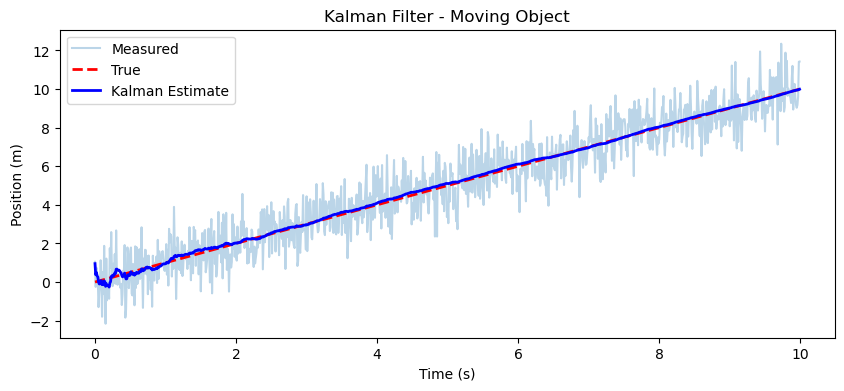

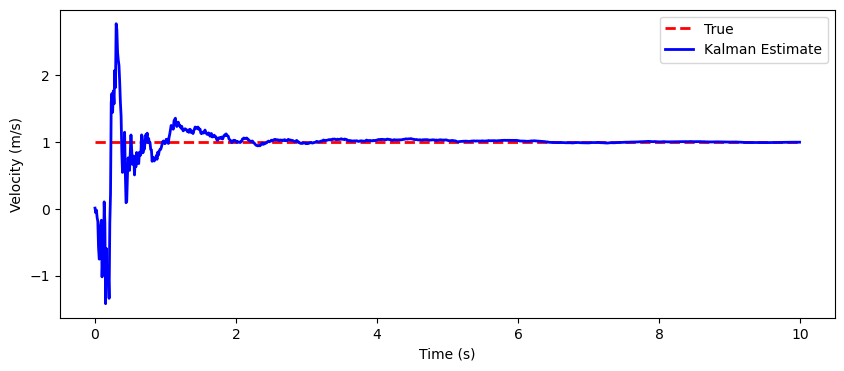

In [13]:
# Kalman Filter for Moving Object

x_0_est = 0.0
v_est = 0.0
X_est_cv = np.array([[x_0_est], [v_est]])
F = np.array([[1, delta_t], [0, 1]])   # F@X(t) = X(t+1)
H = np.array([[1, 0]])                 # extracts position scalar from our X vector during H@X matrix mult.

P = np.array([[10.0, 0.0], [0.0, 10.0]])  # initial uncertainty matrix: P(1,1) = x_0 uncertainty and P(2,2) = v uncertainty
Q = np.array([[0.0, 0.0], [0.0, 0.0]])    # our constant-velocity model describes object perfectly
R = np.array([[1.0]])                     # variance of instrument noise (our random noise has std 1.0),
                                          # R is a scalar here because we only have one sensor

estimates_x_cv = []
estimates_v_cv = []
for val in x_measured_moving:
    X_pred = F @ X_est_cv
    P_pred = F @ P @ F.T + Q    # when performing linear transformation F, multiply F by covariance matrix by F transpose
    S = (H@P_pred@H.T + R)                        # this is "innovation covariance matrix," shows uncertainty of innovation vector,
    K = (P_pred @ H.T) @ np.linalg.inv(S)         # which is the difference between measurement and prediction
    P = (np.eye(2) - K @ H) @ P_pred
    # generate new x estimate:
    X_est_cv = X_pred + K @ (np.array([[val]]) - H @ X_pred)
    estimates_x_cv.append(float(X_est_cv[0, 0]))
    estimates_v_cv.append(float(X_est_cv[1, 0]))

# position plot
plt.figure(figsize = (10, 4))
plt.plot(t, x_measured_moving, alpha = 0.3, label = 'Measured')
plt.plot(t, x_true_moving, 'r--', linewidth = 2, label = 'True')
plt.plot(t, estimates_x_cv, 'b-', linewidth = 2, label = 'Kalman Estimate')
plt.title('Kalman Filter - Moving Object')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.legend()
plt.show()

# velocity plot
plt.figure(figsize = (10, 4))
plt.plot(t, v_true_array, 'r--', linewidth = 2, label = 'True')
plt.plot(t, estimates_v_cv, 'b-', linewidth = 2, label = 'Kalman Estimate')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.show()


## Drifting Velocity Target

#### Models a target whose velocity fluctuates slightly around a setpoint, like someone walking or a bicycle on a flat road

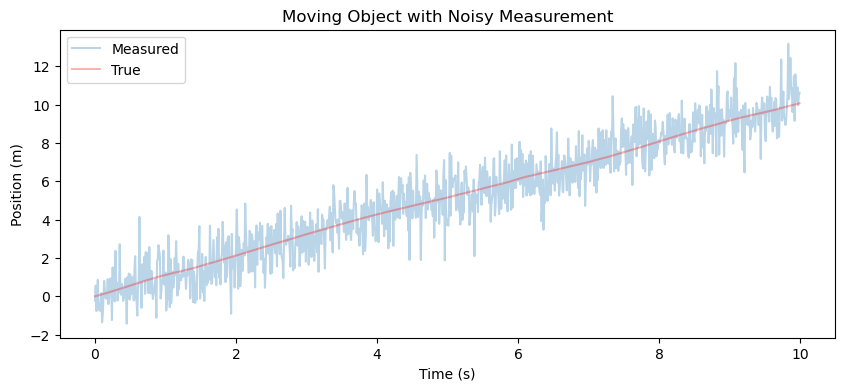

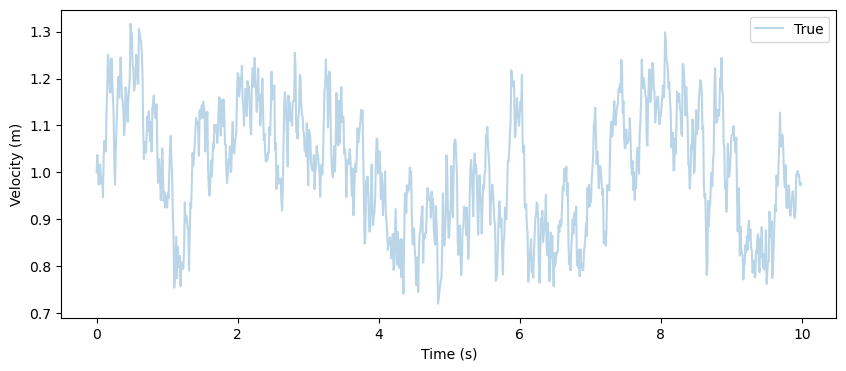

In [14]:
# Generating Position Data for Drifting Target

drift = 0.05           # std of velocity drift each delta_t, crank this and drift_thresh up to ~5 to push kalman filter to its limits
drift_thresh = 0.2     # maximum drift from v_initial that we are comfortable with

v_true_dr = [v_true]   # setting first entry in velocity list to v_true
x_true_dr = [x_0_true]
for i in range(len(t[1:])):
    x_true_dr.append(x_true_dr[i] + v_true_dr[i]*delta_t)  
    total_drift = v_true - float(v_true_dr[i])
    if abs(total_drift) < drift_thresh:
        v_true_dr.append(np.random.normal(v_true_dr[i], drift))         # the changes in velocity must be somewhat smooth
    else:
        v_true_dr.append(v_true_dr[i] + np.sign(total_drift) * abs(np.random.normal(0.0, drift)))    # if velocity has drifted too far,
                                                                                                     # bring it back closer to initial v
x_measured_dr = np.array(x_true_dr) + np.random.normal(0.0, sensor_noise, size=len(t))

plt.figure(figsize=(10,4))
plt.plot(t, x_measured_dr, alpha = 0.3, label = 'Measured')
plt.plot(t, x_true_dr, 'r-', alpha=0.3, label = 'True')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Moving Object with Noisy Measurement')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(t, v_true_dr, alpha = 0.3, label = 'True')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m)')
plt.legend()
plt.show()


In [15]:
# Kalman Filter for drift-velocity target

from ipywidgets import interact, FloatSlider
from scipy import signal

def kalman(log_q_val):
    q_val = 10 ** log_q_val
    print(f'Model Covariance = {q_val:.4f}')   
    
    X_est_dr = np.array([[x_0_est], [v_est]])
    F = np.array([[1, delta_t], [0, 1]])   # F@X(t) = X(t+1)
    H = np.array([[1, 0]])                 # extracts position scalar from our X vector during H@X matrix mult.
    
    P = np.array([[10.0, 0.0], [0.0, 10.0]])  # initial uncertainty matrix: P(1,1) = x_0 uncertainty and P(2,2) = v uncertainty
    Q = np.array([[0.0, 0.0], [0.0, q_val]])   # our constant-velocity model describes object well, but not ideally
    R = np.array([[1.0]])                     # variance of instrument noise (our random noise has std 1.0),
                                              # R is a scalar here because we only have one sensor
    
    estimates_x_dr = []
    estimates_v_dr = []
    innovations = []
    for val in x_measured_dr:
        X_pred = F @ X_est_dr
        P_pred = F @ P @ F.T + Q    # when performing linear transformation F, multiply F by covariance matrix by F transpose
        innovation = np.array([[val]]) - H @ X_pred
        innovations.append(float(innovation[0,0]))
        S = (H@P_pred@H.T + R)                        # this is "innovation covariance matrix," shows uncertainty of innovation vector,
        K = (P_pred @ H.T) @ np.linalg.inv(S)         # which is the difference between measurement and prediction
        P = (np.eye(2) - K @ H) @ P_pred
        # generate new x estimate:
        X_est_dr = X_pred + K @ innovation
        estimates_x_dr.append(float(X_est_dr[0, 0]))
        estimates_v_dr.append(float(X_est_dr[1, 0]))
    
    # position plot
    plt.figure(figsize = (10, 4))
    plt.plot(t, x_measured_dr, alpha = 0.3, label = 'Measured')
    plt.plot(t, x_true_dr, 'r--', linewidth = 2, label = 'True')
    plt.plot(t, estimates_x_dr, 'b-', linewidth = 2, label = 'Kalman Estimate')
    plt.title('Kalman Filter - Drift-Velocity Target')
    plt.xlabel('Time (s)')
    plt.ylabel('Position (m)')
    plt.legend()
    plt.show()
    
    # velocity plot
    plt.figure(figsize = (10, 4))
    plt.plot(t, v_true_dr, 'r--', linewidth = 2, label = 'True')
    plt.plot(t, estimates_v_dr, 'b-', linewidth = 2, label = 'Kalman Estimate')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.legend()
    plt.show()
    
    # PSD plot for innovation sequence
    # We only have position measurements, so innovation sequence is disparities between prediction and measured
    # A well-tuned power spectral density is flat, which means no bias at certain frequency components
    
    freqs, Pxx= signal.welch(np.array(innovations), fs=1/delta_t)
    
    plt.figure(figsize=(10,4))
    plt.semilogy(freqs, Pxx)
    white_perf = np.mean(Pxx) * np.ones_like(Pxx)
    plt.semilogy(freqs, white_perf, 'r--', alpha=0.5, label='Theoretical white')
    plt.legend()
    plt.ylim([1e-4, 1e-1])
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectral Density (m$^2$/Hz)')
    plt.title('Innovation Sequence PSD')
    plt.show()

    flatness = np.std(Pxx) / np.mean(Pxx)
    print(f'PSD flatness: {flatness: .3f}')
    



interact(kalman, log_q_val=FloatSlider(min=-5, max=1, step=0.1, value=-2, description='', readout=False));

interactive(children=(FloatSlider(value=-2.0, description='log_q_val', max=1.0, min=-5.0, readout=False), Outp…

### Optimal Q for velocity depends on drift and drift threshold parameters. The closer the model behaves to constant velocity, the lower our Q.

# Terrain Generation

### Begin with some flat ground, then transition to incline, then decline back to original elevation.

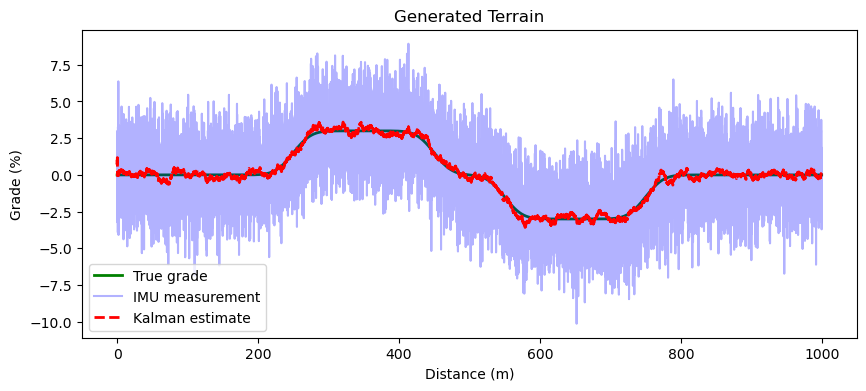

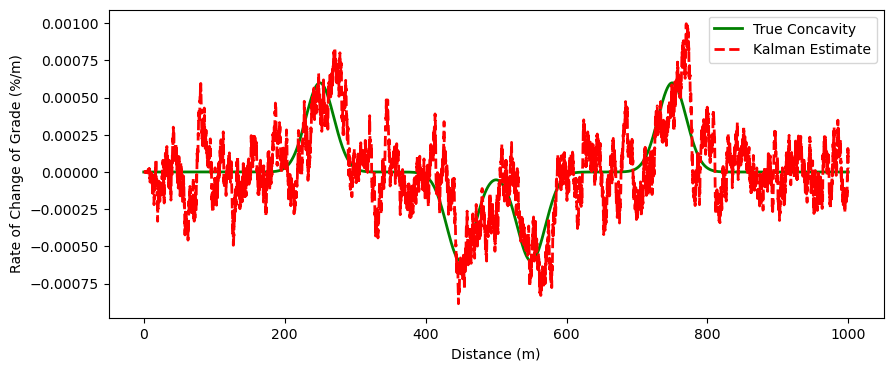

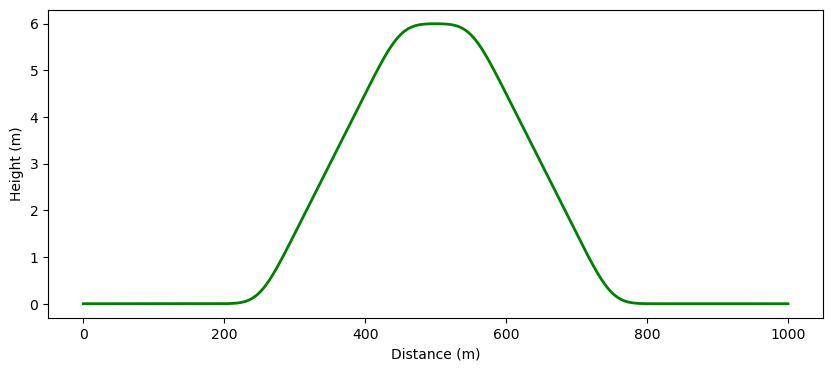

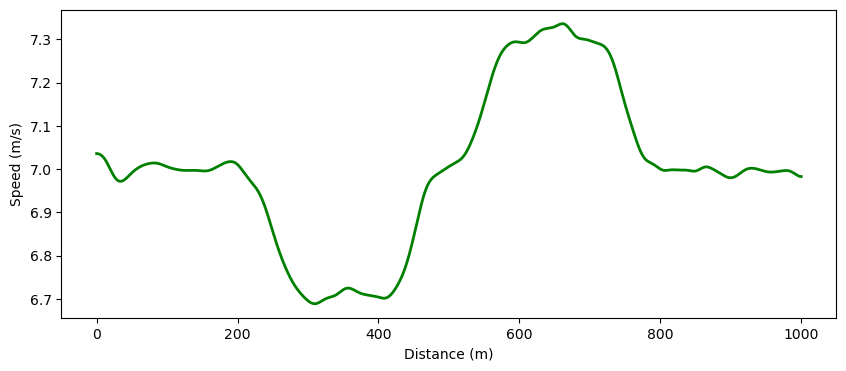

In [77]:
from scipy.ndimage import gaussian_filter1d

dx = .1
dist = 1000
pos_x = np.arange(0, dist, dx)

x_len = len(pos_x)
grade_true = np.zeros(x_len)
grade_true[25 * x_len // 100: 45 * x_len // 100] = 0.03
grade_true[55 * x_len // 100: 75 * x_len // 100] = -0.03
grade_true = gaussian_filter1d(grade_true, sigma=200) # smooth out grade transitions

dgdx_true = np.concatenate([[0], np.diff(grade_true) / dx]) # making the very first element 0 to preserve vector length

imu_noise_std = 0.02
grade_measured = grade_true + np.random.normal(0, imu_noise_std, x_len)


# rider model
v_flat = 7      # 7 m/s ~= 16 mph
grade_variance = 10  # approximating a linear relationship between speed and grade. Will update in later models.
v_model = np.full(x_len, v_flat) - 10 * grade_true
v_noise = gaussian_filter1d(np.random.normal(0, 0.2, len(pos_x)), sigma=100)  # rider won't maintain precise speed
v_true_spatial = v_model + v_noise


# time to deploy the kalman filter.

g_0_est = 0.0    # inital grade estimate
dgdx_est = 0.0     # initial dg/dx estimate
G_est = np.array([[g_0_est], [dgdx_est]])
F = np.array([[1, dx], [0, 1]])        # F@G(s) = G(x+1)
H = np.array([[1, 0]])                 # extracts grade scalar from our G vector during H@G matrix mult.

P = np.array([[imu_noise_std**2, 0.0], [0.0, 1e-10]])  # initial uncertainty matrix: P(1,1) = g_0 uncertainty and P(2,2) = dgdx uncertainty
Q = np.array([[0.0, 0.0], [0.0, 1e-9]])     # our constant-dgdx model describes target very well, but not perfectly. Try setting to <1e-10, and see what I mean
R = np.array([[imu_noise_std ** 2]])        # variance of instrument noise (our random noise has set std)

estimates_g = []
estimates_dgdx = []
for val in grade_measured:
    G_pred = F @ G_est
    P_pred = F @ P @ F.T + Q    # when performing linear transformation F, multiply F by covariance matrix by F transpose
    S = (H@P_pred@H.T + R)                        # this is "innovation covariance matrix," shows uncertainty of innovation vector,
    K = (P_pred @ H.T) @ np.linalg.inv(S)         # which is the difference between measurement and prediction
    P = (np.eye(2) - K @ H) @ P_pred
    # generate new x estimate:
    G_est = G_pred + K @ (np.array([[val]]) - H @ G_pred)
    estimates_g.append(float(G_est[0, 0]))
    estimates_dgdx.append(float(G_est[1, 0]))



plt.figure(figsize=(10,4))
plt.plot(pos_x, grade_true * 100, 'g-', linewidth=2, label='True grade')
plt.plot(pos_x, grade_measured * 100, 'b-', alpha=0.3, label='IMU measurement')
plt.plot(pos_x, np.array(estimates_g) * 100, 'r--', linewidth=2, label='Kalman estimate')
plt.xlabel('Distance (m)')
plt.ylabel('Grade (%)')
plt.title('Generated Terrain')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(pos_x, dgdx_true, 'g-', linewidth=2, label = 'True Concavity')
plt.plot(pos_x, estimates_dgdx, 'r--', linewidth=2, label='Kalman Estimate')
plt.xlabel('Distance (m)')
plt.ylabel('Rate of Change of Grade (%/m)')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
y_true = cumulative_trapezoid(grade_true, dx=dx, initial=0)
plt.plot(pos_x, y_true, 'g-', linewidth=2, label='Terrain')
plt.xlabel('Distance (m)')
plt.ylabel('Height (m)')
plt.show()

plt.figure(figsize=(10,4))
plt.plot(pos_x, v_true_spatial, 'g-', linewidth=2, label='Terrain')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (m/s)')
plt.show()

## Indexing position and velocity to equidistant time steps

In [48]:
from scipy.integrate import trapezoid, cumulative_trapezoid
from scipy.interpolate import interp1d


t_total = trapezoid(1 / v_true_spatial, dx=dx) # finding total time by integrating reciprocal of velocity over x
t = np.arange(0, t_total, delta_t)

t_x = cumulative_trapezoid(1/v_true_spatial, dx=dx, initial = 0)   # gives a time value for each position measurement
x_t = interp1d(t_x, pos_x)                                         # approximates an x function for time input
x_true_t = x_t(t)

v_t = interp1d(t_x, v_true_spatial)
v_true_t = v_t(t)
